# Modelado del Índice de Aptitud Agrícola (IAI)

Este notebook entrena y evalúa modelos de regresión para predecir el IAI a partir de
variables climáticas y edáficas. El enfoque de este notebook es **global** (un solo modelo
para toda California). Al final se revisa el R² por condado; ese análisis es el que motiva
la decisión de pasar a un **modelado por cluster** en un notebook posterior.

Se trabaja con dos métricas: **R²** y **WMAPE** (Weighted Mean Absolute Percentage Error).
Además se registran los tiempos de entrenamiento e inferencia de cada modelo, que servirán
para el análisis de costos, y todas las figuras se exportan en **PDF vectorial** para LaTeX.

## Librerías

In [1]:
# Manipulación de datos
import polars as pl
import pandas as pd
import numpy as np

# Modelos
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import optuna

# Utilidades
import time
import os
import joblib

# Mapas y gráficos
import geopandas as gpd
import requests, zipfile, io
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe
optuna.logging.set_verbosity(optuna.logging.WARNING)





c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuración de salidas y figuras

Las figuras se guardan en formato PDF vectorial. Este formato conserva la resolución al
escalar dentro de LaTeX y evita el pixelado de los mapas. Se configura matplotlib para que
las fuentes queden incrustadas como texto editable (`fonttype 42`), lo que permite que el
compilador de LaTeX las trate correctamente.

In [2]:
# Directorios de salida
OUTPUT_DIR = "C:/Users/lesli/Documents/TFM/notebooks/ML_outputs"
FIG_DIR    = os.path.join(OUTPUT_DIR, "figuras_latex")
MODELS_DIR = "C:/Users/lesli/Documents/TFM/modelos"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Configuración de matplotlib para calidad de publicación (LaTeX)
mpl.rcParams.update({
    "pdf.fonttype":      42,      # fuentes incrustadas como texto
    "ps.fonttype":       42,
    "font.family":       "serif",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "legend.fontsize":   8,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "figure.dpi":        150,     # solo afecta la vista en pantalla
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

def guardar_figura(fig, nombre):
    """Guarda una figura en PDF vectorial dentro de FIG_DIR."""
    ruta = os.path.join(FIG_DIR, f"{nombre}.pdf")
    fig.savefig(ruta, format="pdf", bbox_inches="tight")
    print(f"Figura guardada: {ruta}")

print(f"Salidas en:  {OUTPUT_DIR}")
print(f"Figuras en:  {FIG_DIR}")

Salidas en:  C:/Users/lesli/Documents/TFM/notebooks/ML_outputs
Figuras en:  C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex


## Métricas: R² y WMAPE

Se usan dos métricas complementarias. El **R²** mide qué proporción de la varianza del IAI
explica el modelo, por lo que sirve para comparar el ajuste general. El **WMAPE** mide el
error absoluto total como porcentaje del valor real acumulado:

$$ \text{WMAPE} = \frac{\sum_i |y_i - \hat{y}_i|}{\sum_i |y_i|} \times 100 $$

Se eligió el WMAPE en lugar del MAPE clásico porque el IAI toma valores cercanos a cero en
algunas parcelas, y el MAPE se dispara cuando el denominador es pequeño. El WMAPE pondera por
la magnitud real y evita ese problema, por lo que da una medida de error más estable.

In [3]:
def wmape(y_true, y_pred):
    """Weighted Mean Absolute Percentage Error (en %)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return 100.0 * np.sum(np.abs(y_true - y_pred)) / denom


def calcular_metricas(y_true, y_pred):
    """Devuelve R², WMAPE, RMSE y MAE de un conjunto."""
    return {
        "r2":    r2_score(y_true, y_pred),
        "wmape": wmape(y_true, y_pred),
        "rmse":  np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae":   mean_absolute_error(y_true, y_pred),
    }

## Carga y limpieza de datos

In [4]:
df_model = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai_v3.parquet")

print(f"Observaciones: {df_model.shape[0]:,} | Columnas: {df_model.shape[1]}")
df_model.head(5)


Observaciones: 633,904 | Columnas: 49


year,crop_id,crop_name,is_target,location,processed,ppt,processed_climate,tmax,tmean,tmin,vpdmax,vpdmin,awc_r,cec7_r,claytotal_r,dbthirdbar_r,ec_r,ksat_r,om_r,ph1to1h2o_r,processed_soil,profundidad_efectiva_cm,sandtotal_r,silttotal_r,sumbases_r,es_proyeccion,hurs_245,hurs_585,pr_245,pr_585,referencia_base,tmax_245,tmax_585,tmean_245,tmean_585,tmin_245,tmin_585,vpdmean,lon,lat,vpdmean_245,vpdmean_585,county,I_temp,I_frio,I_precip,I_suelo,IAI
i64,i64,str,bool,struct[2],bool,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,bool,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
2008,2,"""Cotton""",true,"{""Point"",[-120.703207, 37.125374]}",false,203.770004,true,23.848001,15.783001,7.719,22.509001,1.777,0.15,15.0,31.0,1.35,3.0,2.7,0.75,8.2,true,30.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,12.143,-120.703207,37.125374,null,null,"""Merced""",1.0,1.0,0.0,0.55,0.6825
2008,212,"""Oranges""",true,"{""Point"",[-119.113253, 35.622238]}",false,129.257004,true,24.682001,17.624001,10.568001,25.107,4.256,0.17,24.4,31.0,1.45,0.0,9.0,0.75,7.9,true,46.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,14.6815,-119.113253,35.622238,null,null,"""Kern""",1.0,1.0,0.0,0.391304,0.658696
2008,3,"""Rice""",true,"{""Point"",[-121.880199, 39.018031]}",false,370.766022,true,23.924002,16.358002,8.792001,23.787001,2.398,0.16,48.5,59.299999,1.18,0.9,0.42,3.99,6.8,true,9.0,0.9,39.799999,45.0,null,null,null,null,null,null,null,null,null,null,null,null,13.0925,-121.880199,39.018031,null,null,"""Colusa""",1.0,1.0,0.0,0.666667,0.7
2008,75,"""Almonds""",true,"{""Point"",[-119.128831, 35.717057]}",false,131.94101,true,24.880001,17.76,10.641001,25.513,4.177,0.11,7.5,15.0,1.55,1.0,28.0,0.75,7.9,true,28.0,65.900002,19.1,null,null,null,null,null,null,null,null,null,null,null,null,null,14.845,-119.128831,35.717057,null,null,"""Kern""",1.0,1.0,0.0,0.366667,0.655
2008,69,"""Grapes""",true,"{""Point"",[-120.119889, 37.04136]}",false,206.222015,true,24.250002,16.461,8.673,24.395,2.449,0.09,8.1,15.0,1.55,1.0,5.5,1.0,6.3,true,23.0,66.0,19.0,6.9,null,null,null,null,null,null,null,null,null,null,null,null,13.422,-120.119889,37.04136,null,null,"""Madera""",1.0,1.0,0.0,0.591026,0.688654


In [6]:
# Columnas de proyecciones climáticas y referencias que no se usan en el modelado
columnas_a_eliminar = [
    "hurs_245", "hurs_585", "pr_245", "pr_585",
    "referencia_base", "tmax_245", "tmax_585",
    "tmean_245", "tmean_585", "tmin_245", "tmin_585", "es_proyeccion", "vpdmax", "vpdmin"
]
df_model = df_model.drop(columnas_a_eliminar)

print(f"Observaciones: {df_model.shape[0]:,} | Columnas: {df_model.shape[1]}")
df_model.head(5)

Observaciones: 633,904 | Columnas: 35


year,crop_id,crop_name,is_target,location,processed,ppt,processed_climate,tmax,tmean,tmin,awc_r,cec7_r,claytotal_r,dbthirdbar_r,ec_r,ksat_r,om_r,ph1to1h2o_r,processed_soil,profundidad_efectiva_cm,sandtotal_r,silttotal_r,sumbases_r,vpdmean,lon,lat,vpdmean_245,vpdmean_585,county,I_temp,I_frio,I_precip,I_suelo,IAI
i64,i64,str,bool,struct[2],bool,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
2008,2,"""Cotton""",true,"{""Point"",[-120.703207, 37.125374]}",false,203.770004,true,23.848001,15.783001,7.719,0.15,15.0,31.0,1.35,3.0,2.7,0.75,8.2,true,30.0,35.400002,33.599998,null,12.143,-120.703207,37.125374,null,null,"""Merced""",1.0,1.0,0.0,0.55,0.6825
2008,212,"""Oranges""",true,"{""Point"",[-119.113253, 35.622238]}",false,129.257004,true,24.682001,17.624001,10.568001,0.17,24.4,31.0,1.45,0.0,9.0,0.75,7.9,true,46.0,35.400002,33.599998,null,14.6815,-119.113253,35.622238,null,null,"""Kern""",1.0,1.0,0.0,0.391304,0.658696
2008,3,"""Rice""",true,"{""Point"",[-121.880199, 39.018031]}",false,370.766022,true,23.924002,16.358002,8.792001,0.16,48.5,59.299999,1.18,0.9,0.42,3.99,6.8,true,9.0,0.9,39.799999,45.0,13.0925,-121.880199,39.018031,null,null,"""Colusa""",1.0,1.0,0.0,0.666667,0.7
2008,75,"""Almonds""",true,"{""Point"",[-119.128831, 35.717057]}",false,131.94101,true,24.880001,17.76,10.641001,0.11,7.5,15.0,1.55,1.0,28.0,0.75,7.9,true,28.0,65.900002,19.1,null,14.845,-119.128831,35.717057,null,null,"""Kern""",1.0,1.0,0.0,0.366667,0.655
2008,69,"""Grapes""",true,"{""Point"",[-120.119889, 37.04136]}",false,206.222015,true,24.250002,16.461,8.673,0.09,8.1,15.0,1.55,1.0,5.5,1.0,6.3,true,23.0,66.0,19.0,6.9,13.422,-120.119889,37.04136,null,null,"""Madera""",1.0,1.0,0.0,0.591026,0.688654


## Split geográfico por condado

El split se hace por condado y no de forma aleatoria. Se eligió esta estrategia porque las
parcelas de un mismo condado comparten clima y suelo, y un split aleatorio dejaría parcelas
casi idénticas en train y test, lo que inflaría las métricas. Al separar condados completos,
el conjunto de test evalúa la capacidad del modelo de generalizar a zonas no vistas.

Se asignaron los condados de alta densidad del Valle Central al entrenamiento, y las zonas
geográficamente distintas al test, buscando una proporción aproximada de 70 / 10 / 20.

In [7]:
condados_train = [
    'Fresno', 'Kern', 'Tulare', 'Merced', 'San Joaquin',
    'Kings', 'Madera', 'Imperial', 'Stanislaus', 'Colusa', 'Yolo'
]
condados_val = [
    'Glenn', 'Butte', 'Sutter', 'Sacramento',
    'Plumas', 'Mendocino', 'Lake', 'Shasta', 'Santa Clara',
    'Alpine', 'Santa Cruz', 'San Diego', 'El Dorado',
    'Calaveras', 'Marin', 'San Mateo', 'Nevada', 'Humboldt'
]
condados_test = [
    'Riverside', 'Mono', 'Modoc', 'Siskiyou', 'Lassen',
    'Solano', 'Monterey', 'Sonoma', 'Yuba', 'San Luis Obispo',
    'Napa', 'Santa Barbara', 'San Bernardino', 'Tehama',
    'Contra Costa', 'Placer', 'Inyo', 'San Benito', 'Ventura',
    'Alameda', 'Sierra', 'Amador', 'Los Angeles', 'Trinity',
    'Orange', 'Tuolumne', 'Mariposa', 'Del Norte'
]

df_model = df_model.with_columns(
    pl.when(pl.col('county').is_in(condados_train)).then(pl.lit('train'))
      .when(pl.col('county').is_in(condados_val)).then(pl.lit('val'))
      .when(pl.col('county').is_in(condados_test)).then(pl.lit('test'))
      .otherwise(pl.lit('sin_asignar'))
      .alias('split_zona')
)

# Verificación de la distribución
resumen = df_model.group_by('split_zona').len().sort('len', descending=True)
total = df_model.shape[0]
print(f"{'Zona':<12} | {'Obs':>10} | {'%':>6}")
print('-' * 34)
for r in resumen.iter_rows(named=True):
    print(f"{r['split_zona']:<12} | {r['len']:>10,} | {100*r['len']/total:>5.1f}%")
print('-' * 34)
print(f"{'TOTAL':<12} | {total:>10,} | 100.0%")

sin_asignar = df_model.filter(pl.col('split_zona') == 'sin_asignar').shape[0]
print(f"\nCondados sin asignar: {sin_asignar}")

Zona         |        Obs |      %
----------------------------------
train        |    444,625 |  70.1%
test         |    116,280 |  18.3%
val          |     72,999 |  11.5%
----------------------------------
TOTAL        |    633,904 | 100.0%

Condados sin asignar: 0


In [8]:
df_train = df_model.filter(pl.col('split_zona') == 'train')
df_val   = df_model.filter(pl.col('split_zona') == 'val')
df_test  = df_model.filter(pl.col('split_zona') == 'test')
print(f"Train: {df_train.shape[0]:,} | Val: {df_val.shape[0]:,} | Test: {df_test.shape[0]:,}")

Train: 444,625 | Val: 72,999 | Test: 116,280


## Cartografía base (Census TIGER)

Se descarga el shapefile de condados de California para los mapas de verificación del split
y del error por condado. Una vez descargado, se filtra el estado de California (FIPS 06).

In [9]:
url_tiger = ("https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip")
print("Descargando shapefile Census TIGER...")
resp = requests.get(url_tiger, timeout=60)
zipfile.ZipFile(io.BytesIO(resp.content)).extractall("/tmp/tiger_counties")

gdf_us = gpd.read_file("/tmp/tiger_counties/tl_2022_us_county.shp")
gdf_counties = (
    gdf_us[gdf_us['STATEFP'] == '06']
    .rename(columns={'NAME': 'name'})
    .to_crs('EPSG:4326')
)
print(f"Condados de California cargados: {len(gdf_counties)}")

Descargando shapefile Census TIGER...
Condados de California cargados: 58


In [10]:
def agregar_norte(ax, x=0.95, y=0.97, size=0.045):
    """
    Añade una flecha de norte estilo cartográfico (mitad negra, mitad blanca)
    en coordenadas relativas al eje (0-1).

    Parámetros
    ----------
    ax   : eje de matplotlib
    x, y : posición del centro de la flecha (relativa al eje, 0-1)
    size : tamaño relativo de la flecha
    """
    fig = ax.get_figure()
    ax_bbox = ax.get_position()

    # Convertir coordenadas relativas al eje en coordenadas de figura
    cx = ax_bbox.x0 + x * ax_bbox.width
    cy = ax_bbox.y0 + y * ax_bbox.height

    h = size * 1.8   # altura de la flecha
    w = size * 0.55  # semi-ancho de la base

    # Mitad izquierda (negra)
    tri_izq = plt.Polygon(
        [[cx - w, cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx,     cy - h * 0.55]],
        transform=fig.transFigure,
        color='black', zorder=10, clip_on=False
    )

    # Mitad derecha (blanca con borde negro)
    tri_der = plt.Polygon(
        [[cx,     cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx + w, cy - h * 0.55]],
        transform=fig.transFigure,
        color='white', zorder=10, clip_on=False,
        ec='black', linewidth=0.8
    )

    # Contorno exterior
    contorno = plt.Polygon(
        [[cx - w, cy - h * 0.55],
         [cx,     cy + h * 0.45],
         [cx + w, cy - h * 0.55]],
        transform=fig.transFigure,
        fill=False, ec='black', linewidth=1.0,
        zorder=11, clip_on=False
    )

    fig.add_artist(tri_izq)
    fig.add_artist(tri_der)
    fig.add_artist(contorno)

    # Letra N
    fig.text(
        cx, cy + h * 0.52,
        'N',
        transform=fig.transFigure,
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color='black', zorder=12,
        path_effects=[pe.withStroke(linewidth=2, foreground='white')]
    )


C:\Users\lesli\AppData\Local\Temp\ipykernel_23100\1041605244.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area_min = gdf_split.geometry.area.quantile(0.15)


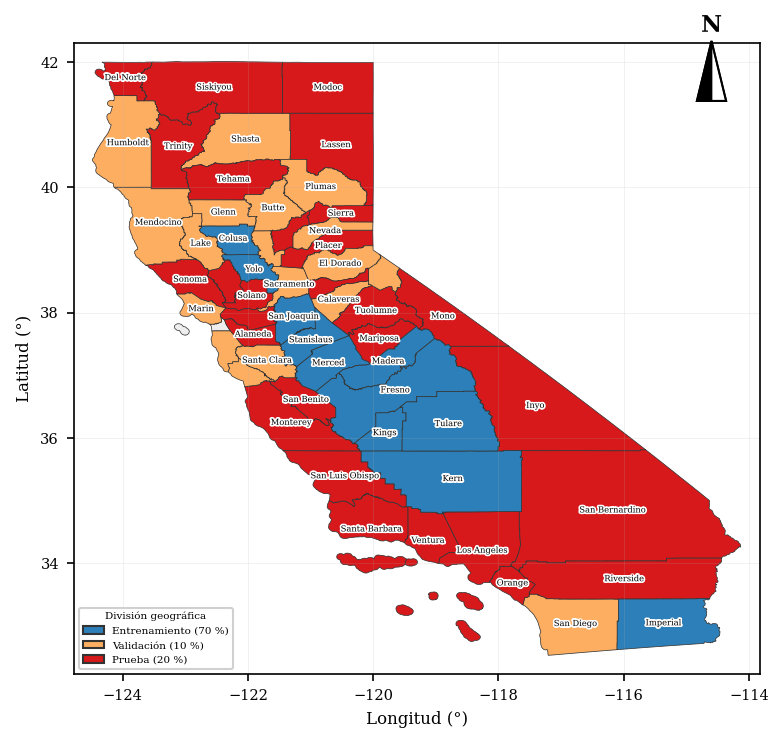

In [11]:
# ── Mapa de verificación visual del split ──
# Generado al tamaño final de impresión para preservar la legibilidad

FS_TITULO   = 11
FS_EJES     = 8
FS_TICKS    = 7
FS_LEYENDA  = 5
FS_CONDADO  = 4    # antes 4.5

colores_split = {
    'train': '#2c7fb8',
    'val':   '#fdae61',
    'test':  '#d7191c'
}

split_por_condado = (
    df_model
    .group_by(['county', 'split_zona'])
    .len()
    .to_pandas()
)
condado_split_map = dict(zip(
    split_por_condado['county'],
    split_por_condado['split_zona']
))

gdf_split = gdf_counties.copy()
gdf_split['split_zona'] = gdf_split['name'].map(condado_split_map)
gdf_split['color'] = gdf_split['split_zona'].map(colores_split).fillna('#eeeeee')

# Tamaño final: 5,9" de ancho = \textwidth de 15 cm
fig, ax = plt.subplots(figsize=(5.9, 7.4))

gdf_split.plot(
    ax=ax,
    color=gdf_split['color'],
    edgecolor='#333333',
    linewidth=0.35
)

# ── Etiquetas de condado ──
# Se omiten los condados más pequeños, donde el nombre no cabe
area_min = gdf_split.geometry.area.quantile(0.15)

for _, row in gdf_split.iterrows():
    if row['split_zona'] in colores_split and row['geometry'].area >= area_min:
        c = row['geometry'].centroid
        ax.annotate(
            row['name'],
            xy=(c.x, c.y),
            fontsize=FS_CONDADO, ha='center', va='center',
            color='black', zorder=5,
            path_effects=[pe.withStroke(linewidth=1.6, foreground='white')]
        )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colores_split['train'], edgecolor='#333', label='Entrenamiento (70 %)'),
    Patch(facecolor=colores_split['val'],   edgecolor='#333', label='Validación (10 %)'),
    Patch(facecolor=colores_split['test'],  edgecolor='#333', label='Prueba (20 %)')
]
ax.legend(handles=legend_elements, loc='lower left',
          fontsize=FS_LEYENDA, title='División geográfica',
          title_fontsize=FS_LEYENDA, framealpha=0.92)

ax.set_xlabel('Longitud (°)', fontsize=FS_EJES)
ax.set_ylabel('Latitud (°)', fontsize=FS_EJES)
ax.tick_params(labelsize=FS_TICKS)
ax.grid(True, alpha=0.2, linewidth=0.4)
ax.set_aspect('equal')

minx, miny, maxx, maxy = gdf_counties.total_bounds
margen = 0.3
ax.set_xlim(minx - margen, maxx + margen)
ax.set_ylim(miny - margen, maxy + margen)

agregar_norte(ax, x=0.93, y=0.96, size=0.030)

plt.savefig(os.path.join(OUTPUT_DIR, '10_split_geografico_nt.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(OUTPUT_DIR, '10_split_geografico_nt.png'), dpi=300, bbox_inches='tight')
plt.show()


## Preparación de las matrices X / y

Se aplica one-hot encoding a la variable `crop_name` para incorporar el tipo de cultivo al
modelo. Como algún cultivo podría no aparecer en val o test, se alinean las columnas one-hot
entre los tres conjuntos para que todos tengan las mismas variables. Los árboles no requieren
escalado, por lo que las variables base se dejan en su escala original.

In [12]:
features_base = [
    "tmax", "tmin", "ppt",                       # clima (= fórmula)
    "ph1to1h2o_r", "awc_r",                      # suelo de la fórmula
    "profundidad_efectiva_cm",                   # AÑADIR: la fórmula la usa
    "claytotal_r", "dbthirdbar_r",               # texturas (información de suelo)
    "sandtotal_r", "silttotal_r",
    # vpdmean QUITADO: baja importancia + problema de homologación futura
]
df_train_oh = df_train.to_dummies(columns=["crop_name"])
df_val_oh   = df_val.to_dummies(columns=["crop_name"])
df_test_oh  = df_test.to_dummies(columns=["crop_name"])

todas_cols_cultivo = sorted(set(
    [c for c in df_train_oh.columns if c.startswith("crop_name_")] +
    [c for c in df_val_oh.columns   if c.startswith("crop_name_")] +
    [c for c in df_test_oh.columns  if c.startswith("crop_name_")]
))

def alinear(df_oh, cols):
    faltantes = [c for c in cols if c not in df_oh.columns]
    for c in faltantes:
        df_oh = df_oh.with_columns(pl.lit(0).cast(pl.UInt8).alias(c))
    return df_oh

df_train_oh = alinear(df_train_oh, todas_cols_cultivo)
df_val_oh   = alinear(df_val_oh,   todas_cols_cultivo)
df_test_oh  = alinear(df_test_oh,  todas_cols_cultivo)

features_modelo = features_base + todas_cols_cultivo

X_train = df_train_oh.select(features_modelo).to_numpy()
y_train = df_train_oh.select("IAI").to_numpy().ravel()
X_val   = df_val_oh.select(features_modelo).to_numpy()
y_val   = df_val_oh.select("IAI").to_numpy().ravel()
X_test  = df_test_oh.select(features_modelo).to_numpy()
y_test  = df_test_oh.select("IAI").to_numpy().ravel()

# Arrays de condado (para CV espacial y analisis por condado)
condados_train_arr = df_train_oh.select("county").to_numpy().ravel()
condados_test_arr = df_test_oh.select("county").to_numpy().ravel()

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"Features: {len(features_modelo)} ({len(features_base)} base + {len(todas_cols_cultivo)} cultivos)")
for nombre, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"  NaN en {nombre}: {np.isnan(X).sum()}")

X_train: (444625, 22) | X_val: (72999, 22) | X_test: (116280, 22)
Features: 22 (10 base + 12 cultivos)
  NaN en train: 0
  NaN en val: 0
  NaN en test: 0


## Función de evaluación con tiempos

La función evalúa un modelo en train, validación y test, y devuelve R² y WMAPE en cada
conjunto. Además mide el **tiempo de inferencia** sobre el test, que después se usa en el
análisis de costos. El tiempo de entrenamiento se mide fuera de la función, en el momento de
ajustar cada modelo, para no incluir en él el costo de la predicción.

In [13]:
def evaluar_modelo(nombre, modelo, tiempo_entrenamiento):
    """Evalua en train/val/test, mide inferencia y devuelve un registro plano."""
    # Tiempo de inferencia: se mide sobre el test
    t0 = time.perf_counter()
    y_test_pred = modelo.predict(X_test)
    t_infer = time.perf_counter() - t0

    y_train_pred = modelo.predict(X_train)
    y_val_pred   = modelo.predict(X_val)

    m_tr = calcular_metricas(y_train, y_train_pred)
    m_v  = calcular_metricas(y_val,   y_val_pred)
    m_te = calcular_metricas(y_test,  y_test_pred)

    reg = {
        'modelo': nombre,
        'r2_train': m_tr['r2'], 'r2_val': m_v['r2'], 'r2_test': m_te['r2'],
        'wmape_train': m_tr['wmape'], 'wmape_val': m_v['wmape'], 'wmape_test': m_te['wmape'],
        'rmse_val': m_v['rmse'], 'mae_val': m_v['mae'],
        'gap_r2': m_tr['r2'] - m_v['r2'],
        't_entrenamiento_s': tiempo_entrenamiento,
        't_inferencia_test_s': t_infer,
        'ms_por_1000_obs': 1000 * t_infer / len(y_test),
    }

    print(f"\n{'='*54}\n  {nombre}\n{'='*54}")
    print(f"  R2    train: {m_tr['r2']:.4f} | val: {m_v['r2']:.4f} | test: {m_te['r2']:.4f}")
    print(f"  WMAPE train: {m_tr['wmape']:.2f}% | val: {m_v['wmape']:.2f}% | test: {m_te['wmape']:.2f}%")
    print(f"  Tiempo entren.: {tiempo_entrenamiento:.1f}s | inferencia test: {t_infer:.3f}s")
    if reg['gap_r2'] > 0.1:
        print(f"  Posible sobreajuste (gap R2 = {reg['gap_r2']:.3f})")
    return reg

resultados_modelos = []

## Modelos base

Se entrenan tres modelos de árboles con hiperparámetros razonables como línea base: Random
Forest, XGBoost y LightGBM. El objetivo es tener una referencia antes de optimizar, y
comparar su desempeño y su costo de entrenamiento.

In [14]:
# Random Forest
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=300, max_depth=20, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)
t_rf = time.time() - t0
resultados_modelos.append(evaluar_modelo("Random Forest", rf, t_rf))


  Random Forest
  R2    train: 0.9957 | val: 0.8886 | test: 0.8351
  WMAPE train: 0.53% | val: 2.58% | test: 4.31%
  Tiempo entren.: 81.4s | inferencia test: 1.919s
  Posible sobreajuste (gap R2 = 0.107)


## Optimización de hiperparámetros (LightGBM y XGBoost)

Se optimizan los dos modelos de gradient boosting con Optuna. La búsqueda usa validación
cruzada espacial por condado (`GroupKFold` sobre los condados de train), de modo que cada fold
valida en condados que el modelo no vio durante ese ajuste. Esto mantiene la coherencia con el
split geográfico y evita medir el desempeño sobre parcelas demasiado parecidas.

El criterio de optimización es el **WMAPE de validación cruzada** (se minimiza). Para cada
combinación probada se ajusta además un modelo sobre todo el train y se registran R² y WMAPE
en train, validación y test. De esta forma queda una grilla completa con el desempeño de cada
combinación en los tres conjuntos. El test se guarda solo para reporte; la selección del mejor
modelo se hace por la métrica de validación cruzada.

In [15]:
# CV espacial por condado
N_FOLDS_CV = 5
gkf = GroupKFold(n_splits=N_FOLDS_CV)
print(f"Condados en train: {len(np.unique(condados_train_arr))} | Folds: {N_FOLDS_CV}")

# Registro global de todas las combinaciones probadas
registro_grid = []

def registrar_combinacion(modelo_nombre, trial_num, params, modelo_full, cv_wmape, t_fit):
    """Ajusta metricas train/val/test de una combinacion y la agrega al registro."""
    m_tr = calcular_metricas(y_train, modelo_full.predict(X_train))
    m_v  = calcular_metricas(y_val,   modelo_full.predict(X_val))
    m_te = calcular_metricas(y_test,  modelo_full.predict(X_test))
    fila = {
        'modelo': modelo_nombre,
        'trial': trial_num,
        'cv_wmape_val': cv_wmape,
        'r2_train': m_tr['r2'], 'r2_val': m_v['r2'], 'r2_test': m_te['r2'],
        'wmape_train': m_tr['wmape'], 'wmape_val': m_v['wmape'], 'wmape_test': m_te['wmape'],
        't_fit_full_s': t_fit,
    }
    fila.update({f"param_{k}": v for k, v in params.items()})
    registro_grid.append(fila)

Condados en train: 11 | Folds: 5


In [16]:
# Objetivo XGBoost
def objetivo_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 500),
        'max_depth':        trial.suggest_categorical('max_depth', [4, 5, 8]),
        'learning_rate':    trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1]),
        'subsample':        trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'random_state': 42, 'n_jobs': -1, 'early_stopping_rounds': 20
    }
    # CV espacial: WMAPE medio
    wmape_folds = []
    for idx_tr, idx_val in gkf.split(X_train, y_train, groups=condados_train_arr):
        m = xgb.XGBRegressor(**params)
        m.fit(
            X_train[idx_tr], y_train[idx_tr],
            eval_set=[(X_train[idx_val], y_train[idx_val])],
            verbose=False
        )
        wmape_folds.append(wmape(y_train[idx_val], m.predict(X_train[idx_val])))
    cv_wmape = float(np.mean(wmape_folds))

    # Modelo sobre todo el train para registrar train/val/test
    t0 = time.time()
    m_full = xgb.XGBRegressor(**params)
    m_full.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    t_fit = time.time() - t0
    registrar_combinacion("XGBoost", trial.number, params, m_full, cv_wmape, t_fit)
    return cv_wmape

print("Optimizando XGBoost (Optuna + CV espacial, minimizando WMAPE)...")
study_xgb = optuna.create_study(direction='minimize', study_name='xgb_spatial')
study_xgb.optimize(objetivo_xgb, n_trials=40, show_progress_bar=True)
print(f"\nMejor WMAPE CV: {study_xgb.best_value:.3f}%")
print("Mejores hiperparametros XGBoost:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

Optimizando XGBoost (Optuna + CV espacial, minimizando WMAPE)...


Best trial: 36. Best value: 1.14602: 100%|██████████| 40/40 [1:07:09<00:00, 100.73s/it]


Mejor WMAPE CV: 1.146%
Mejores hiperparametros XGBoost:
  n_estimators: 352
  max_depth: 8
  learning_rate: 0.05
  subsample: 1.0
  colsample_bytree: 0.9549247450731501
  reg_alpha: 0.02116995713780594
  reg_lambda: 0.004185287861823514
  min_child_weight: 6


In [17]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning,
)

In [18]:
# Objetivo LightGBM
def objetivo_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_categorical('n_estimators', [200, 400, 600]),
        'max_depth':         trial.suggest_categorical('max_depth', [4, 8, 14]),
        'num_leaves':        trial.suggest_categorical('num_leaves', [20, 50, 100]),
        'learning_rate':     trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1]),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    }
    wmape_folds = []
    for idx_tr, idx_val in gkf.split(X_train, y_train, groups=condados_train_arr):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train[idx_tr], y_train[idx_tr],
              eval_set=[(X_train[idx_val], y_train[idx_val])],
              callbacks=[lgb.early_stopping(30, verbose=False)])
        wmape_folds.append(wmape(y_train[idx_val], m.predict(X_train[idx_val])))
    cv_wmape = float(np.mean(wmape_folds))
    t0 = time.time()
    m_full = lgb.LGBMRegressor(**params)
    m_full.fit(X_train, y_train, eval_set=[(X_val, y_val)],
               callbacks=[lgb.early_stopping(30, verbose=False)])
    t_fit = time.time() - t0
    registrar_combinacion("LightGBM", trial.number, params, m_full, cv_wmape, t_fit)
    return cv_wmape

print("Optimizando LightGBM (Optuna + CV espacial, minimizando WMAPE)...")
study_lgb = optuna.create_study(direction='minimize', study_name='lgb_spatial')
study_lgb.optimize(objetivo_lgb, n_trials=40, show_progress_bar=True)
print(f"\nMejor WMAPE CV: {study_lgb.best_value:.3f}%")
print("Mejores hiperparametros LightGBM:")
for k, v in study_lgb.best_params.items():
    print(f"  {k}: {v}")

Optimizando LightGBM (Optuna + CV espacial, minimizando WMAPE)...


  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 34. Best value: 1.07291: 100%|██████████| 40/40 [1:04:08<00:00, 96.22s/it] 


Mejor WMAPE CV: 1.073%
Mejores hiperparametros LightGBM:
  n_estimators: 600
  max_depth: 14
  num_leaves: 100
  learning_rate: 0.05
  subsample: 0.7066630797062178
  colsample_bytree: 0.9768651210123868
  reg_alpha: 0.008475263137091873
  reg_lambda: 0.22277518949953587
  min_child_samples: 92


## Grilla de resultados de la búsqueda

Se consolidan todas las combinaciones probadas de ambos modelos en un solo DataFrame, con sus
métricas en train, validación y test. Esta tabla es la que permite comparar el efecto de cada
combinación de hiperparámetros y se exporta a CSV para el análisis posterior.

In [19]:
df_grid = pl.DataFrame(registro_grid).sort('cv_wmape_val')
cols_frente = ['modelo', 'trial', 'cv_wmape_val',
               'wmape_train', 'wmape_val', 'wmape_test',
               'r2_train', 'r2_val', 'r2_test', 't_fit_full_s']
otras = [c for c in df_grid.columns if c not in cols_frente]
df_grid = df_grid.select(cols_frente + otras)

# Ver la tabla completa en el notebook (todas las filas y columnas)
with pl.Config(tbl_rows=-1, tbl_cols=-1, fmt_str_lengths=100):
    print(df_grid)

# Exportar a Excel
ruta_excel = os.path.join(OUTPUT_DIR, "grid_hiperparametros_metricas.xlsx")
df_grid.write_excel(ruta_excel)
print(f"Exportado a: {ruta_excel}")

shape: (80, 24)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ mod ┆ tri ┆ cv_ ┆ wma ┆ wma ┆ wma ┆ r2_ ┆ r2_ ┆ r2_ ┆ t_f ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par │
│ elo ┆ al  ┆ wma ┆ pe_ ┆ pe_ ┆ pe_ ┆ tra ┆ val ┆ tes ┆ it_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ │
│ --- ┆ --- ┆ pe_ ┆ tra ┆ val ┆ tes ┆ in  ┆ --- ┆ t   ┆ ful ┆ n_e ┆ max ┆ lea ┆ sub ┆ col ┆ reg ┆ reg ┆ min ┆ ran ┆ n_j ┆ ear ┆ num ┆ min ┆ ver │
│ str ┆ i64 ┆ val ┆ in  ┆ --- ┆ t   ┆ --- ┆ f64 ┆ --- ┆ l_s ┆ sti ┆ _de ┆ rni ┆ sam ┆ sam ┆ _al ┆ _la ┆ _ch ┆ dom ┆ obs ┆ ly_ ┆ _le ┆ _ch ┆ bos │
│     ┆     ┆ --- ┆ --- ┆ f64 ┆ --- ┆ f64 ┆     ┆ f64 ┆ --- ┆ mat ┆ pth ┆ ng_ ┆ ple ┆ ple ┆ pha ┆ mbd ┆ ild ┆ _st ┆ --- ┆ sto ┆ ave ┆ ild ┆ e   │
│     ┆     ┆ f64 ┆ f64 ┆     ┆ f64 ┆     ┆     ┆     ┆ f64 ┆ ors ┆ --- ┆ rat ┆ --- ┆ _by ┆ --- ┆ a   ┆ _we 

## Red Neuronal

In [20]:
def entrenar_red_combo(X_tr, y_tr, X_va, y_va, n_base,
                       max_epochs=100, patience=15, seed=42):
    """Entrena una RedIAI sobre las features dadas. Escala solo las
    primeras n_base columnas (continuas), no las one-hot."""
    torch.manual_seed(seed); np.random.seed(seed)

    scaler = StandardScaler()
    X_tr_sc = X_tr.copy().astype(np.float32)
    X_va_sc = X_va.copy().astype(np.float32)
    if n_base > 0:
        X_tr_sc[:, :n_base] = scaler.fit_transform(X_tr[:, :n_base])
        X_va_sc[:, :n_base] = scaler.transform(X_va[:, :n_base])

    tr_loader = DataLoader(TensorDataset(
        torch.tensor(X_tr_sc), torch.tensor(y_tr, dtype=torch.float32).view(-1,1)),
        batch_size=512, shuffle=True)
    va_loader = DataLoader(TensorDataset(
        torch.tensor(X_va_sc), torch.tensor(y_va, dtype=torch.float32).view(-1,1)),
        batch_size=512, shuffle=False)

    modelo = RedIAI(input_dim=X_tr_sc.shape[1]).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-5)

    mejor_val, mejor_pesos, pc = float('inf'), None, 0
    for epoch in range(max_epochs):
        modelo.train()
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(modelo(X_b), y_b)
            loss.backward(); optimizer.step()
        modelo.eval()
        vl, n = 0.0, 0
        with torch.no_grad():
            for X_b, y_b in va_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                vl += criterion(modelo(X_b), y_b).item() * len(X_b); n += len(X_b)
        vl /= n
        if vl < mejor_val:
            mejor_val, mejor_pesos, pc = vl, copy.deepcopy(modelo.state_dict()), 0
        else:
            pc += 1
        if pc >= patience:
            break
    modelo.load_state_dict(mejor_pesos)
    return modelo, scaler

def predecir_combo(modelo, scaler, X, n_base):
    modelo.eval()
    X_sc = X.copy().astype(np.float32)
    if n_base > 0:
        X_sc[:, :n_base] = scaler.transform(X[:, :n_base])
    with torch.no_grad():
        return modelo(torch.tensor(X_sc).to(device)).cpu().numpy().ravel()

In [21]:
# Mapa nombre -> índice de columna (features_base son las primeras de X_train)
idx = {nombre: i for i, nombre in enumerate(features_base)}
n_base_total = len(features_base)
idx_onehot = list(range(n_base_total, X_train.shape[1]))  # one-hot al final

print("Features base disponibles:", features_base)

# Combinaciones a probar, adaptadas a las features actuales
combos_nombres = {
    "todas":         features_base,
    "solo_clima":    [f for f in features_base if f in
                      ["tmax", "tmin", "ppt"]],
    "clima_suelo_basico": [f for f in features_base if f in
                      ["tmax", "tmin", "ppt", "ph1to1h2o_r", "awc_r",
                       "profundidad_efectiva_cm"]],
    "sin_texturas":  [f for f in features_base if f not in
                      ["claytotal_r", "sandtotal_r", "silttotal_r", "dbthirdbar_r"]],
}

# Convertir nombres a índices
combinaciones = {k: [idx[f] for f in v] for k, v in combos_nombres.items()}
for k, v in combos_nombres.items():
    print(f"  {k}: {len(v)} features -> {v}")

Features base disponibles: ['tmax', 'tmin', 'ppt', 'ph1to1h2o_r', 'awc_r', 'profundidad_efectiva_cm', 'claytotal_r', 'dbthirdbar_r', 'sandtotal_r', 'silttotal_r']
  todas: 10 features -> ['tmax', 'tmin', 'ppt', 'ph1to1h2o_r', 'awc_r', 'profundidad_efectiva_cm', 'claytotal_r', 'dbthirdbar_r', 'sandtotal_r', 'silttotal_r']
  solo_clima: 3 features -> ['tmax', 'tmin', 'ppt']
  clima_suelo_basico: 6 features -> ['tmax', 'tmin', 'ppt', 'ph1to1h2o_r', 'awc_r', 'profundidad_efectiva_cm']
  sin_texturas: 6 features -> ['tmax', 'tmin', 'ppt', 'ph1to1h2o_r', 'awc_r', 'profundidad_efectiva_cm']


## Grilla de resultados de la búsqueda

Se consolidan todas las combinaciones probadas de ambos modelos en un solo DataFrame, con sus
métricas en train, validación y test. Esta tabla es la que permite comparar el efecto de cada
combinación de hiperparámetros y se exporta a CSV para el análisis posterior.

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import copy, time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [23]:
class RedIAI(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [24]:
filas = []
for nombre, idx_base in combinaciones.items():
    t0 = time.time()
    cols = list(idx_base) + idx_onehot
    X_tr, X_va, X_te = X_train[:, cols], X_val[:, cols], X_test[:, cols]
    n_base = len(idx_base)

    modelo, scaler = entrenar_red_combo(X_tr, y_train, X_va, y_val, n_base)
    p_tr = predecir_combo(modelo, scaler, X_tr, n_base)
    p_va = predecir_combo(modelo, scaler, X_va, n_base)
    p_te = predecir_combo(modelo, scaler, X_te, n_base)

    # Usar tu función calcular_metricas
    m_tr = calcular_metricas(y_train, p_tr)
    m_va = calcular_metricas(y_val,   p_va)
    m_te = calcular_metricas(y_test,  p_te)

    filas.append({
        "combinacion": nombre, "n_features": n_base,
        "R2_train": m_tr["r2"],  "R2_val": m_va["r2"],  "R2_test": m_te["r2"],
        "WMAPE_train": m_tr["wmape"], "WMAPE_val": m_va["wmape"], "WMAPE_test": m_te["wmape"],
        "RMSE_test": m_te["rmse"], "MAE_test": m_te["mae"],
        "tiempo_s": round(time.time()-t0, 1),
    })
    print(f"[{nombre}] R2 tr/va/te = {m_tr['r2']:.3f}/{m_va['r2']:.3f}/{m_te['r2']:.3f} | {filas[-1]['tiempo_s']}s")

grid_nn = pd.DataFrame(filas)

[todas] R2 tr/va/te = 0.987/0.875/0.654 | 2548.4s
[solo_clima] R2 tr/va/te = 0.931/0.827/0.743 | 1111.5s
[clima_suelo_basico] R2 tr/va/te = 0.989/0.887/0.745 | 1665.6s
[sin_texturas] R2 tr/va/te = 0.989/0.887/0.745 | 1523.5s


In [25]:
grid_nn["gap_R2"] = (grid_nn["R2_train"] - grid_nn["R2_test"]).abs()
grid_nn["rango_R2"] = (grid_nn[["R2_train","R2_val","R2_test"]].max(axis=1)
                       - grid_nn[["R2_train","R2_val","R2_test"]].min(axis=1))
grid_nn["gap_WMAPE"] = (grid_nn["WMAPE_train"] - grid_nn["WMAPE_test"]).abs()

grid_nn.to_excel("grid_nn_features.xlsx", index=False)
grid_nn.sort_values("gap_R2").round(4)

,combinacion,n_features,R2_train,R2_val,R2_test,WMAPE_train,WMAPE_val,WMAPE_test,RMSE_test,MAE_test,tiempo_s,gap_R2,rango_R2,gap_WMAPE
1,solo_clima,3,0.9314,0.8266,0.7435,2.9151,3.1384,4.8911,0.0560,0.0343,1111.5,0.1879,0.1879,1.9760
2,clima_suelo_basico,6,0.9893,0.8871,0.7454,0.9480,1.9507,4.4451,0.0558,0.0312,1665.6,0.2439,0.2439,3.4971
3,sin_texturas,6,0.9893,0.8871,0.7454,0.9480,1.9507,4.4451,0.0558,0.0312,1523.5,0.2439,0.2439,3.4971
0,todas,10,0.9871,0.8751,0.6538,1.1701,1.9793,5.2057,0.0651,0.0365,2548.4,0.3332,0.3332,4.0356


In [26]:
R2_TEST_MIN = 0.85   # ajusta a tu umbral de "buen desempeño"
GAP_MAX     = 0.1   # diferencia train-test máxima aceptable

candidatos = grid_nn[(grid_nn["R2_test"] >= R2_TEST_MIN) &
                     (grid_nn["gap_R2"] <= GAP_MAX)].copy()

if candidatos.empty:
    print("Ninguna combinación cumple ambos umbrales. Las 3 más estables:")
    display(grid_nn.sort_values("gap_R2").head(3).round(4))
else:
    candidatos = candidatos.sort_values(["gap_R2","R2_test"], ascending=[True, False])
    print(f"{len(candidatos)} combinaciones cumplen. La mejor (estable + buen R2):")
    display(candidatos.round(4))
    print(f"\n>>> Combinación elegida: {candidatos.iloc[0]['combinacion']}")

Ninguna combinación cumple ambos umbrales. Las 3 más estables:


,combinacion,n_features,R2_train,R2_val,R2_test,WMAPE_train,WMAPE_val,WMAPE_test,RMSE_test,MAE_test,tiempo_s,gap_R2,rango_R2,gap_WMAPE
1,solo_clima,3,0.9314,0.8266,0.7435,2.9151,3.1384,4.8911,0.0560,0.0343,1111.5,0.1879,0.1879,1.9760
2,clima_suelo_basico,6,0.9893,0.8871,0.7454,0.9480,1.9507,4.4451,0.0558,0.0312,1665.6,0.2439,0.2439,3.4971
3,sin_texturas,6,0.9893,0.8871,0.7454,0.9480,1.9507,4.4451,0.0558,0.0312,1523.5,0.2439,0.2439,3.4971


In [27]:
# ── LightGBM (trial 15) ──
params_lgb = {
    "n_estimators":     600,
    "max_depth":        14,
    "learning_rate":    0.1,
    "subsample":        0.78268035,
    "colsample_bytree": 0.96200307,
    "reg_alpha":        0.0023698,
    "reg_lambda":       0.34164788,
    "num_leaves":       50,
    "min_child_samples": 85,
    "random_state":     42,
    "n_jobs":           -1,
    "verbose":          -1,
}
modelo_lgb = lgb.LGBMRegressor(**params_lgb)
modelo_lgb.fit(X_train, y_train)
print("LightGBM reentrenado.")

LightGBM reentrenado.


In [28]:
# ── XGBoost (trial 4) ──
params_xgb = {
    "n_estimators":      456,
    "max_depth":         8,
    "learning_rate":     0.1,
    "subsample":         0.6,
    "colsample_bytree":  0.666,
    "reg_alpha":         0.043,
    "reg_lambda":        1.089,
    "min_child_weight":  15,
    "random_state":      42,
    "n_jobs":            -1,
}
modelo_xgb = xgb.XGBRegressor(**params_xgb)
modelo_xgb.fit(X_train, y_train)
print("XGBoost reentrenado.")

XGBoost reentrenado.


In [29]:
# Confirmar que el reentrenamiento reproduce las métricas delgrid
for nombre, modelo in [("LightGBM", modelo_lgb), ("XGBoost", modelo_xgb)]:
    m_tr = calcular_metricas(y_train, modelo.predict(X_train))
    m_va = calcular_metricas(y_val,   modelo.predict(X_val))
    m_te = calcular_metricas(y_test,  modelo.predict(X_test))
    print(f"{nombre}:")
    print(f"  R²    tr/va/te = {m_tr['r2']:.3f} / {m_va['r2']:.3f} / {m_te['r2']:.3f}")
    print(f"  WMAPE tr/va/te = {m_tr['wmape']:.2f} / {m_va['wmape']:.2f} / {m_te['wmape']:.2f}\n")

LightGBM:
  R²    tr/va/te = 0.999 / 0.951 / 0.862
  WMAPE tr/va/te = 0.20 / 0.96 / 3.21

XGBoost:
  R²    tr/va/te = 0.999 / 0.949 / 0.858
  WMAPE tr/va/te = 0.24 / 1.24 / 3.46



In [30]:
condados_test_arr = df_test_oh.select("county").to_numpy().ravel()
y_pred_test = modelo_lgb.predict(X_test)

filas = []
for cond in np.unique(condados_test_arr):
    mask = condados_test_arr == cond
    n = int(mask.sum())
    if n < 2:
        continue
    y_c, p_c = y_test[mask], y_pred_test[mask]
    filas.append({
        "condado": cond, "n_test": n,
        "r2": r2_score(y_c, p_c),
        "wmape": wmape(y_c, p_c),
        "std_iai": float(np.std(y_c)),
        "iai_medio": float(np.mean(y_c)),
    })

r2_cond = pd.DataFrame(filas).sort_values("r2")
print("=== PEORES 10 ===")
print(r2_cond.head(10).round(4).to_string(index=False))
print("\n=== MEJORES 10 ===")
print(r2_cond.tail(10).round(4).to_string(index=False))
print(f"\nR² mediano: {r2_cond['r2'].median():.3f} | Condados R²<0: {(r2_cond['r2']<0).sum()}")
print(f"Correlación std_iai vs R²: {r2_cond['std_iai'].corr(r2_cond['r2']):.3f}")

=== PEORES 10 ===
  condado  n_test          r2   wmape  std_iai  iai_medio
Del Norte       3 -20473.1982 38.9637   0.0017     0.6367
     Inyo    1875     -3.5201  8.6936   0.0296     0.6333
  Trinity      27     -1.2569 13.0989   0.0762     0.7625
   Sonoma    4786     -0.2654 10.8192   0.1016     0.7934
    Modoc   10537     -0.1987  7.2773   0.0493     0.6511
     Mono   11374      0.0690  2.4681   0.0247     0.6717
     Napa    3404      0.3006  6.4833   0.1015     0.8292
 Tuolumne      19      0.4791  5.0372   0.1442     0.8361
   Lassen    9870      0.6743  3.9268   0.0609     0.6868
 Siskiyou   10174      0.7025  6.5777   0.1018     0.6987

=== MEJORES 10 ===
        condado  n_test     r2  wmape  std_iai  iai_medio
San Luis Obispo    5151 0.9023 1.6646   0.0817     0.7370
     San Benito    1205 0.9071 1.3574   0.0761     0.7465
         Placer    2021 0.9752 0.7464   0.0735     0.7496
 San Bernardino    3227 0.9794 0.9305   0.0729     0.6014
         Tehama    4777 0.9805 0.9

In [31]:
# La clave: separar condados donde el R2 engaña (std baja) de los que fallan de verdad
print("Relación entre R² bajo y varianza del IAI:\n")

# Condados con R2 malo
malos = r2_cond[r2_cond["r2"] < 0.5]
print(f"Condados con R² < 0,5: {len(malos)}")
print(f"  Su std_iai media:  {malos['std_iai'].mean():.4f}")
print(f"  Su WMAPE medio:    {malos['wmape'].mean():.2f}")

# Condados con R2 bueno
buenos = r2_cond[r2_cond["r2"] >= 0.9]
print(f"\nCondados con R² >= 0,9: {len(buenos)}")
print(f"  Su std_iai media:  {buenos['std_iai'].mean():.4f}")
print(f"  Su WMAPE medio:    {buenos['wmape'].mean():.2f}")

# Correlación entre std y R2: si es positiva, el R2 bajo se explica por std baja
print(f"\nCorrelación std_iai vs R²: {r2_cond['std_iai'].corr(r2_cond['r2']):.3f}")


Relación entre R² bajo y varianza del IAI:

Condados con R² < 0,5: 8
  Su std_iai media:  0.0661
  Su WMAPE medio:    11.61

Condados con R² >= 0,9: 10
  Su std_iai media:  0.0815
  Su WMAPE medio:    0.85

Correlación std_iai vs R²: 0.517


In [33]:
# Comprobar si los peores condados tienen condiciones no vistas en train
peores = r2_cond.head(5)["condado"].tolist()
print("Peores condados:", peores, "\n")

# Rangos de train por variable
print(f"{'variable':16s} {'train_min':>10} {'train_max':>10} | por condado malo")
for col in ["tmax", "tmin", "ppt", "profundidad_efectiva_cm", "ph1to1h2o_r"]:
    tr = df_train.select(col).to_numpy().ravel()
    linea = f"{col:16s} {tr.min():>10.1f} {tr.max():>10.1f} |"
    for cond in peores:
        val = df_test.filter(pl.col("county") == cond).select(col).to_numpy().ravel()
        if len(val) > 0:
            fuera = "" if tr.min() <= val.mean() <= tr.max() else " (!)"
            linea += f" {val.mean():.1f}{fuera}"
    print(linea)
print("\nLas marcas (!) indican condados con valores fuera del rango de entrenamiento.")

Peores condados: ['Del Norte', 'Inyo', 'Trinity', 'Sonoma', 'Modoc'] 

variable          train_min  train_max | por condado malo
tmax                    5.4       32.6 | 14.0 18.1 20.4 22.5 17.8
tmin                   -6.2       20.0 | 7.9 -0.7 5.3 7.5 1.0
ppt                    11.5     1505.9 | 1897.5 (!) 201.6 1308.8 909.5 279.3
profundidad_efectiva_cm        1.0      203.0 | 6.3 31.9 24.6 27.5 26.3
ph1to1h2o_r             4.5        9.8 | 6.2 7.4 6.4 6.2 7.3

Las marcas (!) indican condados con valores fuera del rango de entrenamiento.
